# Experimentos FFT y aplicación
Este notebook consta de dos experimentos que refuerzan el análisis del TFG: por un lado la prueba computacional de la DFT vs FFT, mientras que por otro lado pondremos en práctica la aplicación a compresión de audio.

## Parte I: Comparación computacional entre la DFT directa y la FFT

En esta primera parte, vamos a implementar dos métodos para calcular la Transformada Discreta de Fourier de una señal finita:

1. El cálculo directo a partir de la definición de la DFT.
2. El cálculo mediante la Transformada Rápida de Fourier.

El objetivo final será comprobar experimentalmente que ambos métodos producen la misma transformada, pero que su coste computacional es distinto. En particular, queremos observar la diferencia entre el coste cuadrático de la DFT directa y el coste de orden $n\log n$ de la FFT.

## Implementación de la DFT directa

Recordemos que, con la convención utilizada en el trabajo, si $f:\mathbb{Z}_n\to\mathbb{C}$, su Transformada Discreta de Fourier viene dada por

$$
\widehat f[j]
=
\frac{1}{n}
\sum_{k=0}^{n-1}
f([k])e^{-2\pi ijk/n},
\qquad j=0,\dots,n-1.
$$

La implementación directa consiste en calcular esta suma para cada valor de $j$. Por tanto, para cada coeficiente $\widehat f[j]$ recorremos todos los valores de la señal original.

Primero importamos `numpy`, que utilizaremos para trabajar con vectores y números complejos.

In [76]:
import numpy as np

Ahora definimos una función `dft_directa`. La función recibe un vector de muestras y devuelve el vector de coeficientes de Fourier calculado directamente a partir de la definición.

In [77]:
def dft_directa(f):
    """Calcula la DFT de f usando directamente la definicion."""
    # Convertimos la entrada en un array complejo para operar con exponenciales complejas.
    f = np.asarray(f, dtype=complex)
    n = len(f)

    # Reservamos espacio para los n coeficientes de Fourier.
    f_hat = np.zeros(n, dtype=complex)

    # Para cada frecuencia j calculamos la suma de la definicion de la DFT.
    for j in range(n):
        suma = 0
        for k in range(n):
            suma += f[k] * np.exp(-2j * np.pi * j * k / n)
        # Nuestra convencion incluye el factor de normalizacion 1/n en la transformada.
        f_hat[j] = suma / n

    return f_hat


Probamos la función con una señal sencilla de longitud $4$ para ver que funciona correctamente y devuelve un vector de coeficientes de Fourier.

In [78]:
f = np.array([1, 2, 3, 4], dtype=complex)
dft_directa(f)

array([ 2.5+0.0000000e+00j, -0.5+5.0000000e-01j, -0.5-2.4492936e-16j,
       -0.5-5.0000000e-01j])

## Implementación recursiva de la FFT

A continuación implementamos la Transformada Rápida de Fourier siguiendo la descomposición en muestras pares e impares desarrollada en el trabajo. Si la señal tiene longitud $n=2^m$, escribimos

$$
f_0([\ell])=f([2\ell]),
\qquad
f_1([\ell])=f([2\ell+1]).
$$

La idea es calcular recursivamente las transformadas de $f_0$ y $f_1$, que tienen longitud $n/2$, y después recombinarlas para obtener la transformada de $f$.

Con nuestra convención de normalización, la recombinación viene dada por

$$
\widehat f[j]
=
\frac12
\left(
\widehat{f_0}[j]
+
\omega_n^j\widehat{f_1}[j]
\right),
$$

$$
\widehat f[j+n/2]
=
\frac12
\left(
\widehat{f_0}[j]
-
\omega_n^j\widehat{f_1}[j]
\right),
$$

para $j=0,\dots,n/2-1$, donde $\omega_n=e^{-2\pi i/n}$. Esta es la operación elemental que se repite en cada nivel del algoritmo.

Definimos ahora la función `fft_recursiva`. El caso base será una señal de longitud $1$, cuya transformada coincide con ella misma. Si la longitud es mayor, separamos la señal en muestras pares e impares, calculamos recursivamente sus transformadas y finalmente las combinamos usando las fórmulas anteriores.

In [79]:
def fft_recursiva(f):
    """Calcula la DFT de f mediante una FFT recursiva radix-2."""
    # Trabajamos con valores complejos, como en la definicion matematica de la DFT.
    f = np.asarray(f, dtype=complex)
    n = len(f)

    # Caso base: la DFT de una señal de longitud 1 coincide con la propia señal.
    if n == 1:
        return f

    # Esta implementacion radix-2 divide la señal siempre en dos partes.
    if n % 2 != 0:
        raise ValueError("La longitud de f debe ser una potencia de 2.")

    # Calculamos recursivamente las transformadas de las muestras pares e impares.
    f0_hat = fft_recursiva(f[::2])
    f1_hat = fft_recursiva(f[1::2])

    f_hat = np.zeros(n, dtype=complex)

    # Recombina las dos transformadas pequeñas usando los factores twiddle.
    for j in range(n // 2):
        omega = np.exp(-2j * np.pi * j / n)
        # El factor 0.5 aparece por la normalizacion elegida para la DFT.
        f_hat[j] = 0.5 * (f0_hat[j] + omega * f1_hat[j])
        f_hat[j + n // 2] = 0.5 * (f0_hat[j] - omega * f1_hat[j])

    return f_hat


Probamos la función con la misma señal sencilla de longitud $4$ para ver el funcionamiento.

In [80]:
fft_recursiva(f)

array([ 2.5+0.j , -0.5+0.5j, -0.5+0.j , -0.5-0.5j])

## Comparación de resultados

Una vez implementados ambos métodos, comprobamos que calculan la misma transformada. Para ello aplicamos la DFT directa y la FFT recursiva a la misma señal y comparamos sus salidas.

Mediremos el error máximo

$$
\max_j |\widehat f_{\mathrm{DFT}}[j]-\widehat f_{\mathrm{FFT}}[j]|.
$$

In [81]:
f = np.array([1, 2, 3, 4], dtype=complex)

f_hat_dft = dft_directa(f)
f_hat_fft = fft_recursiva(f)

f_hat_dft, f_hat_fft

(array([ 2.5+0.0000000e+00j, -0.5+5.0000000e-01j, -0.5-2.4492936e-16j,
        -0.5-5.0000000e-01j]),
 array([ 2.5+0.j , -0.5+0.5j, -0.5+0.j , -0.5-0.5j]))

Calculamos ahora la diferencia máxima entre ambos vectores de coeficientes. Si la implementación es correcta, este error debe ser muy pequeño.

In [82]:
error_maximo = np.max(np.abs(f_hat_dft - f_hat_fft))
error_maximo

np.float64(4.47545209131181e-16)

El error obtenido es prácticamente nulo, salvo posibles errores de redondeo numérico. Esto confirma en este ejemplo que la FFT no calcula una transformada distinta, sino la misma DFT mediante una organización más eficiente del cálculo.

## Comparación de tiempos

Una vez comprobado que ambos métodos calculan la misma transformada, comparamos ahora el tiempo necesario para aplicar cada uno de ellos. Esta comparación busca ilustrar experimentalmente la diferencia entre el coste $O(n^2)$ de la DFT directa y el coste $O(n\log n)$ de la FFT.

Para medir tiempos usaremos la función `perf_counter`, que permite medir intervalos pequeños con buena precisión.

In [83]:
from time import perf_counter

Definimos una función auxiliar `medir_tiempo`. Para reducir el efecto de pequeñas variaciones del ordenador, ejecutamos varias veces el método y nos quedamos con el menor tiempo obtenido.

In [84]:
def medir_tiempo(metodo, f, repeticiones=5):
    tiempos = []

    # Repetimos la medicion para reducir el efecto de pequeñas variaciones del sistema.
    for _ in range(repeticiones):
        inicio = perf_counter()
        metodo(f)
        fin = perf_counter()
        tiempos.append(fin - inicio)

    # Tomamos el menor tiempo observado como estimacion estable del coste de ejecucion.
    return min(tiempos)

Probamos la medición con una señal de longitud $64$. Generamos una señal sencilla usando una combinación de senos, suficiente para comparar el comportamiento de ambos algoritmos.

In [85]:
n = 64
k = np.arange(n)
f_prueba = np.sin(2 * np.pi * 3 * k / n) + 0.5 * np.sin(2 * np.pi * 7 * k / n)

tiempo_dft = medir_tiempo(dft_directa, f_prueba)
tiempo_fft = medir_tiempo(fft_recursiva, f_prueba)

tiempo_dft, tiempo_fft

(0.0010954999888781458, 0.00016745802713558078)

Estos dos valores representan, respectivamente, el tiempo empleado por la DFT directa y por la FFT para una señal de longitud $64$. En la siguiente parte repetiremos este cálculo para varios tamaños de entrada.

## Tabla comparativa para varios tamaños

Repetimos ahora la comparación para señales de distintas longitudes. Tomamos tamaños de la forma $n=2^m$, ya que la implementación recursiva de la FFT que estamos usando corresponde al caso radix-2.

Para cada tamaño calcularemos:

- el tiempo de la DFT directa,
- el tiempo de la FFT recursiva,
- el cociente entre ambos tiempos,
- el error máximo entre las dos transformadas.

In [86]:
tamanos = [2**m for m in range(4, 12)]
resultados = []

# Repetimos la comparacion para varios tamaños potencia de 2.
for n in tamanos:
    k = np.arange(n)
    f = np.sin(2 * np.pi * 3 * k / n) + 0.5 * np.sin(2 * np.pi * 7 * k / n)

    # Calculamos la misma transformada con ambos metodos y medimos el error maximo.
    f_hat_dft = dft_directa(f)
    f_hat_fft = fft_recursiva(f)
    error = np.max(np.abs(f_hat_dft - f_hat_fft))

    # Medimos tiempos y guardamos el cociente entre ambos.
    tiempo_dft = medir_tiempo(dft_directa, f)
    tiempo_fft = medir_tiempo(fft_recursiva, f)
    ratio = tiempo_dft / tiempo_fft

    resultados.append([n, tiempo_dft, tiempo_fft, ratio, error])

resultados

[[16,
  7.28330051060766e-05,
  3.3958989661186934e-05,
  2.144734158252073,
  np.float64(1.3910262689614943e-15)],
 [32,
  0.00026775000151246786,
  6.895800470374525e-05,
  3.8827979820872893,
  np.float64(2.741270315860031e-15)],
 [64,
  0.0010525420075282454,
  0.00015870900824666023,
  6.631898334922615,
  np.float64(4.959414934114495e-15)],
 [128,
  0.0042722079961095005,
  0.00036433301283977926,
  11.726107285227721,
  np.float64(1.84572342181111e-14)],
 [256,
  0.017267499992158264,
  0.0007726249750703573,
  22.349135155236002,
  np.float64(1.7408319717028902e-14)],
 [512,
  0.06837987501057796,
  0.0016611670143902302,
  41.16375681567357,
  np.float64(7.197275155955343e-14)],
 [1024,
  0.27177833300083876,
  0.0037075419968459755,
  73.30418191676371,
  np.float64(1.043307862796446e-13)],
 [2048,
  1.0907954169961158,
  0.008295292005641386,
  131.49572266465094,
  np.float64(1.66575020407332e-13)]]

Mostramos la información anterior en forma de tabla para que sea más fácil comparar los resultados.

In [87]:
print(f"{'n':>6} {'DFT directa (s)':>18} {'FFT recursiva (s)':>20} {'ratio':>10} {'error maximo':>16}")
print('-' * 76)

for n, tiempo_dft, tiempo_fft, ratio, error in resultados:
    print(f"{n:6d} {tiempo_dft:18.6e} {tiempo_fft:20.6e} {ratio:10.2f} {error:16.2e}")

     n    DFT directa (s)    FFT recursiva (s)      ratio     error maximo
----------------------------------------------------------------------------
    16       7.283301e-05         3.395899e-05       2.14         1.39e-15
    32       2.677500e-04         6.895800e-05       3.88         2.74e-15
    64       1.052542e-03         1.587090e-04       6.63         4.96e-15
   128       4.272208e-03         3.643330e-04      11.73         1.85e-14
   256       1.726750e-02         7.726250e-04      22.35         1.74e-14
   512       6.837988e-02         1.661167e-03      41.16         7.20e-14
  1024       2.717783e-01         3.707542e-03      73.30         1.04e-13
  2048       1.090795e+00         8.295292e-03     131.50         1.67e-13


La columna `ratio` indica cuántas veces más lenta es la DFT directa frente a la FFT para cada tamaño. Observamos que, a medida que aumenta $n$, este cociente tiende a crecer, reflejando la diferencia entre los costes $O(n^2)$ y $O(n\log n)$.

## Representación gráfica de los tiempos

Finalmente representamos los tiempos obtenidos para visualizar mejor la diferencia de crecimiento entre ambos métodos. Usaremos escala logarítmica en ambos ejes, ya que los tamaños y los tiempos crecen de forma rápida.

In [88]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("../resultados/.matplotlib")))
Path("../resultados/.matplotlib").mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

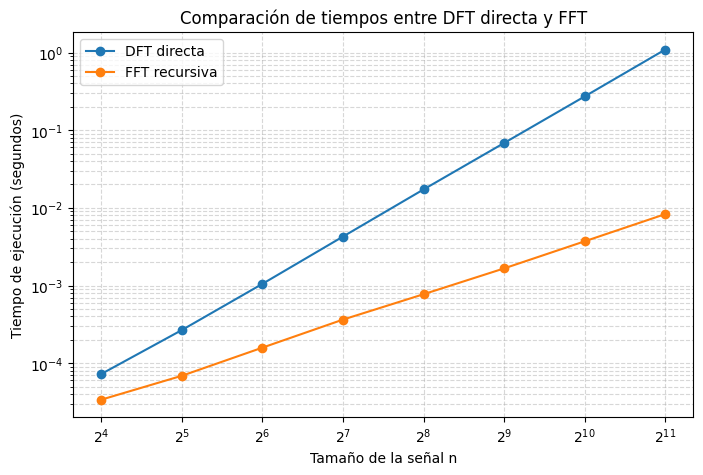

In [89]:
ns = [fila[0] for fila in resultados]
tiempos_dft = [fila[1] for fila in resultados]
tiempos_fft = [fila[2] for fila in resultados]

plt.figure(figsize=(8, 5))
plt.plot(ns, tiempos_dft, marker="o", label="DFT directa")
plt.plot(ns, tiempos_fft, marker="o", label="FFT recursiva")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Tamaño de la señal n")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Comparación de tiempos entre DFT directa y FFT")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

La gráfica muestra que, para tamaños pequeños, la diferencia puede no ser muy grande, ya que intervienen factores propios de la implementación. Sin embargo, al aumentar $n$, la DFT directa crece mucho más rápido que la FFT, de acuerdo con la diferencia teórica entre los costes $O(n^2)$ y $O(n\log n)$.

Guardamos también la figura en formato `.png` para poder incorporarla posteriormente al documento en LaTeX.

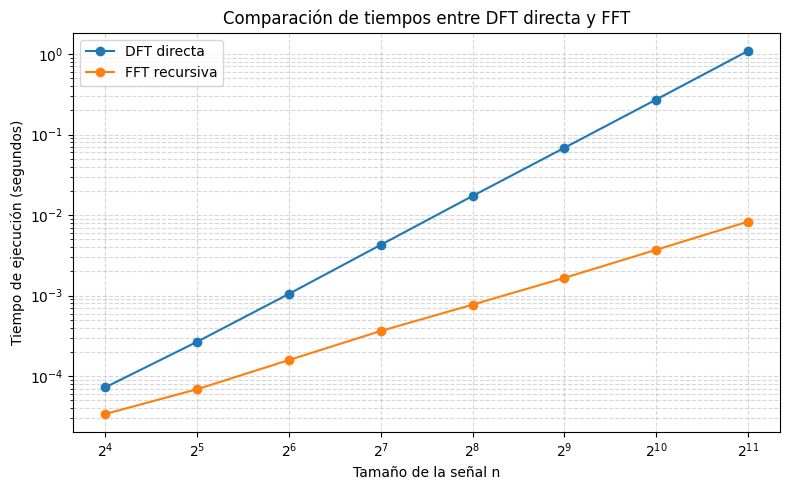

PosixPath('/Users/tomi/Desktop/TFGMAT/scripts/figuras/comparacion_dft_fft.png')

In [90]:
carpeta_figuras = Path.cwd() / "figuras"
carpeta_figuras.mkdir(exist_ok=True)

ruta_figura = carpeta_figuras / "comparacion_dft_fft.png"

plt.figure(figsize=(8, 5))
plt.plot(ns, tiempos_dft, marker="o", label="DFT directa")
plt.plot(ns, tiempos_fft, marker="o", label="FFT recursiva")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Tamaño de la señal n")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Comparación de tiempos entre DFT directa y FFT")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300)
plt.show()

ruta_figura

## Representación gráfica de los tiempos sin escala logarítmica

Representamos ahora los mismos tiempos usando escala lineal en ambos ejes.

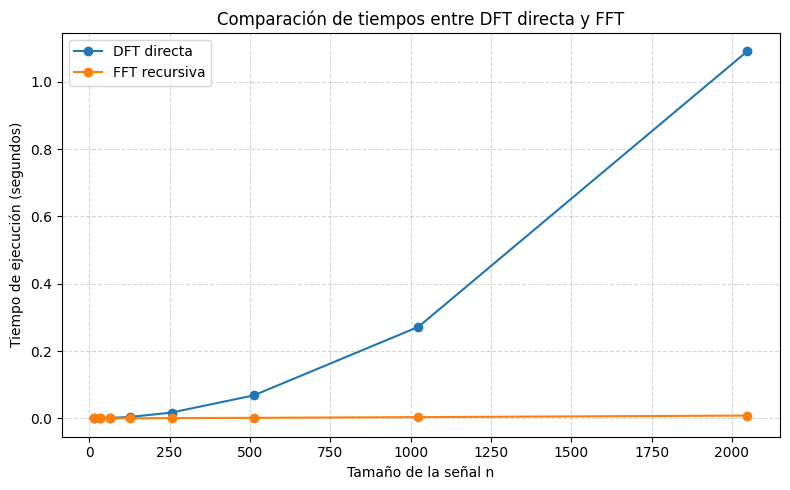

PosixPath('/Users/tomi/Desktop/TFGMAT/scripts/figuras/comparacion_dft_fft_lineal.png')

In [91]:
ruta_figura_lineal = carpeta_figuras / "comparacion_dft_fft_lineal.png"

plt.figure(figsize=(8, 5))
plt.plot(ns, tiempos_dft, marker="o", label="DFT directa")
plt.plot(ns, tiempos_fft, marker="o", label="FFT recursiva")

plt.xlabel("Tamaño de la señal n")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Comparación de tiempos entre DFT directa y FFT")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_figura_lineal, dpi=300)
plt.show()

ruta_figura_lineal

# Parte II: Aplicación a la compresión de audio

En esta segunda parte utilizaremos la FFT para construir un modelo simplificado de compresión de audio. El objetivo será transformar una señal al dominio frecuencial, modificar sus coeficientes y reconstruir una aproximación de la señal original.

## Preparación y carga del audio

Comenzamos cargando el archivo de audio que utilizaremos en la aplicación. Trabajaremos con una señal mono en formato WAV y normalizaremos sus muestras para representarlas como valores reales entre aproximadamente $-1$ y $1$.

In [92]:
import wave
from pathlib import Path

import numpy as np

def buscar_archivo_audio(nombre="audio_original.wav"):
    # Buscamos el archivo aunque el notebook se ejecute desde carpetas distintas.
    for carpeta in [Path.cwd(), *Path.cwd().parents]:
        candidato = carpeta / "audio" / nombre
        if candidato.exists():
            return candidato
    raise FileNotFoundError(f"No se encontro audio/{nombre}")

ruta_audio = buscar_archivo_audio()

# Abrimos el archivo WAV y extraemos sus metadatos principales.
with wave.open(str(ruta_audio), "rb") as archivo_wav:
    Fs = archivo_wav.getframerate()
    num_canales = archivo_wav.getnchannels()
    num_muestras = archivo_wav.getnframes()
    ancho_muestra = archivo_wav.getsampwidth()
    datos = archivo_wav.readframes(num_muestras)

# Para mantener el ejemplo simple, trabajamos con audio PCM de 16 bits.
if ancho_muestra != 2:
    raise ValueError("Este ejemplo espera un archivo WAV PCM de 16 bits.")

# Convertimos los bytes del archivo en un vector de muestras enteras.
audio = np.frombuffer(datos, dtype=np.int16)

# Si el audio fuera estereo, promediariamos los canales para obtener una señal mono.
if num_canales > 1:
    audio = audio.reshape(-1, num_canales).mean(axis=1).astype(np.int16)

Fs, num_canales, audio.shape, audio.dtype


(48000, 1, (300168,), dtype('int16'))

El archivo WAV almacena las muestras como enteros de 16 bits. Para aplicar la FFT y trabajar de forma cómoda con la señal, convertimos estos valores a números reales normalizados, y observamos las características de nuestro audio original.

In [93]:
# Pasamos de enteros de 16 bits a valores reales.
audio = audio.astype(float)

# Normalizamos dividiendo por la amplitud maxima absoluta.
audio = audio / np.max(np.abs(audio))

# La duracion se obtiene dividiendo el numero de muestras entre la frecuencia de muestreo.
duracion = len(audio) / Fs

print(f"Frecuencia de muestreo: {Fs} Hz")
print(f"Numero de muestras: {len(audio)}")
print(f"Duracion: {duracion:.2f} segundos")
print(f"Valor minimo: {audio.min():.3f}")
print(f"Valor maximo: {audio.max():.3f}")


Frecuencia de muestreo: 48000 Hz
Numero de muestras: 300168
Duracion: 6.25 segundos
Valor minimo: -0.952
Valor maximo: 1.000


## Visualización de la señal en el tiempo

Una vez cargado y normalizado el audio, podemos representarlo como señal temporal. Si la frecuencia de muestreo es $F_s$, la muestra situada en la posición $k$ corresponde al instante

$$
t_k=\frac{k}{F_s}.
$$

Esta expresión es la versión computacional de la relación $x_k=x(kT)$, con $T=1/F_s$.

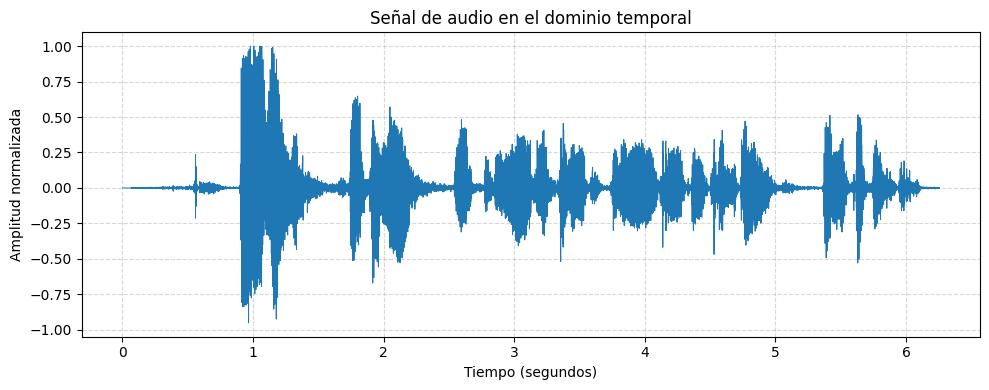

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_senal_temporal.png')

In [94]:
# Construimos el eje temporal asociado a las muestras del audio.
tiempos = np.arange(len(audio)) / Fs

# Guardaremos las figuras en la carpeta de figuras del proyecto.
carpeta_figuras_audio = ruta_audio.parent.parent / "figuras"
carpeta_figuras_audio.mkdir(exist_ok=True)

ruta_figura_audio = carpeta_figuras_audio / "audio_senal_temporal.png"

plt.figure(figsize=(10, 4))
plt.plot(tiempos, audio, linewidth=0.7)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud normalizada")
plt.title("Señal de audio en el dominio temporal")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(ruta_figura_audio, dpi=300)
plt.show()

ruta_figura_audio


La gráfica anterior muestra la evolución completa de la amplitud del audio durante todo el intervalo grabado. Esta representación corresponde al dominio temporal: vemos cómo cambia la señal con el tiempo, pero todavía no qué frecuencias la componen.

La representación completa permite ver la duración y la amplitud global de la señal, pero la forma de onda puede quedar demasiado comprimida. Además, los primeros instantes del audio tienen poca amplitud y no son los más representativos visualmente. Por eso mostramos un intervalo corto posterior, donde la oscilación de la señal se aprecia mejor.

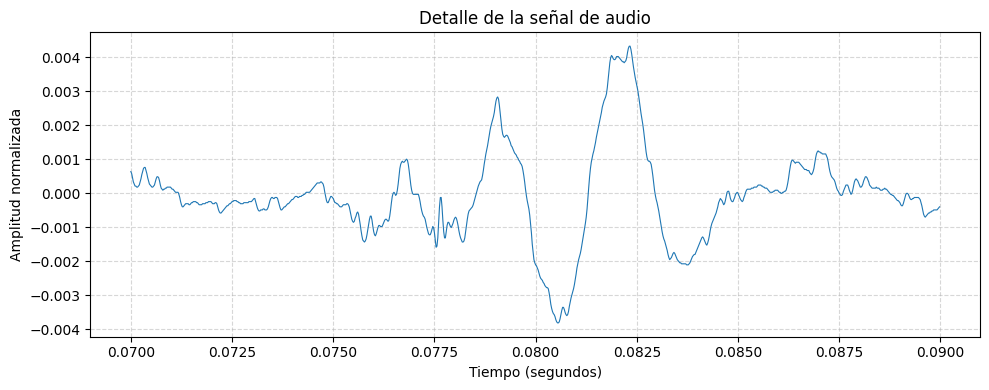

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_senal_temporal_zoom.png')

In [95]:
# Elegimos un tramo corto donde la señal tiene mayor amplitud y se aprecia mejor la forma de onda.
inicio_zoom = 0.07
duracion_zoom = 0.02

muestra_inicio_zoom = int(inicio_zoom * Fs)
muestra_fin_zoom = muestra_inicio_zoom + int(duracion_zoom * Fs)

ruta_figura_audio_zoom = carpeta_figuras_audio / "audio_senal_temporal_zoom.png"

plt.figure(figsize=(10, 4))
plt.plot(tiempos[muestra_inicio_zoom:muestra_fin_zoom], audio[muestra_inicio_zoom:muestra_fin_zoom], linewidth=0.8)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud normalizada")
plt.title("Detalle de la señal de audio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(ruta_figura_audio_zoom, dpi=300)
plt.show()

ruta_figura_audio_zoom


En el detalle inicial se aprecia mejor el carácter oscilatorio local de la señal. Esta oscilación es precisamente la información que analizaremos a continuación mediante la FFT, pasando del dominio temporal al dominio frecuencial.

## Representación frecuencial de un bloque de audio

Para observar el contenido frecuencial del audio trabajaremos primero con un único bloque de la señal. Aunque podríamos transformar el audio completo de una sola vez, en señales de audio es natural trabajar por bloques porque el contenido frecuencial puede variar a lo largo del tiempo. De este modo analizamos una parte concreta de la señal antes de aplicar el procedimiento al audio completo.

Elegimos una longitud $N=4096=2^{12}$, tomamos las primeras $N$ muestras y calculamos su FFT usando la función recursiva definida en la Parte I. Con la convención usada en el trabajo, la transformada viene dada por

$$
\widehat f[j]=\frac{1}{N}\sum_{k=0}^{N-1}f([k])e^{-2\pi ijk/N}.
$$

Como el audio es una señal real, representaremos solo las frecuencias positivas. Esto es suficiente porque, por la simetría conjugada vista anteriormente, la mitad restante del espectro queda determinada por esta parte.

In [96]:
# Elegimos una longitud de bloque potencia de 2 para aplicar nuestra FFT radix-2.
N = 4096

# Tomamos el primer bloque de la señal de audio.
bloque = audio[:N]

# Calculamos la FFT del bloque con la funcion recursiva desarrollada en la Parte I.
bloque_hat = fft_recursiva(bloque)

# Construimos las frecuencias asociadas a los indices de la FFT.
frecuencias = np.fft.fftfreq(N, d=1/Fs)

# Como el bloque es real, mostramos solo la mitad de frecuencias positivas.
frecuencias_positivas = frecuencias[:N // 2]
modulo_positivo = np.abs(bloque_hat[:N // 2])

frecuencias_positivas[:5], modulo_positivo[:5]


(array([ 0.     , 11.71875, 23.4375 , 35.15625, 46.875  ]),
 array([1.84556514e-05, 1.64673455e-05, 1.84942166e-05, 2.80002745e-05,
        3.51700347e-05]))

Representamos ahora el módulo de los coeficientes de Fourier del bloque. Esta gráfica muestra qué frecuencias tienen mayor peso dentro de este fragmento inicial del audio.

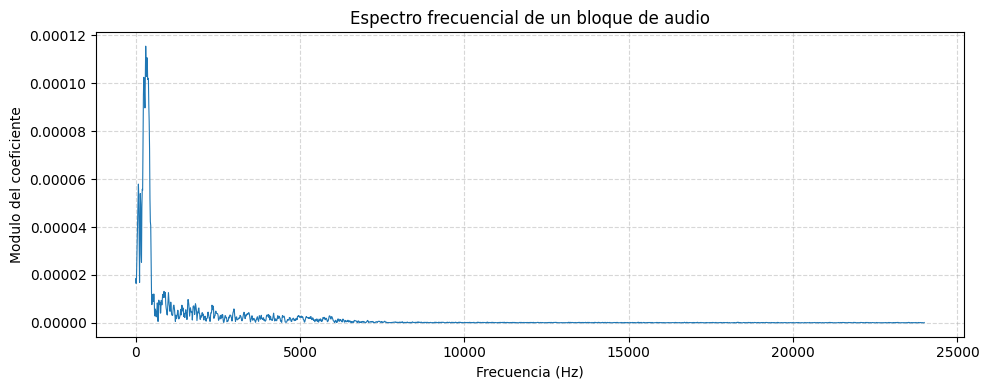

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_espectro_bloque.png')

In [ ]:
ruta_figura_espectro_bloque = carpeta_figuras_audio / "audio_espectro_bloque.png"

plt.figure(figsize=(10, 4))
plt.plot(frecuencias_positivas, modulo_positivo, linewidth=0.8)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Modulo del coeficiente")
plt.title("Espectro frecuencial de un bloque de audio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(ruta_figura_espectro_bloque, dpi=300)
plt.show()

ruta_figura_espectro_bloque


En el espectro se observa que la energía del bloque no está repartida uniformemente entre todas las frecuencias. Algunas componentes tienen un módulo mucho mayor que otras. Esta concentración es la que aprovecharemos en la compresión: modificaremos los coeficientes en el dominio frecuencial y después reconstruiremos la señal mediante la transformada inversa.

En este bloque hemos usado nuestra implementación recursiva para mantener la conexión directa con el algoritmo desarrollado. Una vez probado que podemos calcular la fft con nuestra implementación, para procesar todo el audio bloque a bloque, utilizaremos `np.fft.fft` y `np.fft.ifft`, que son implementaciones optimizadas de la misma transformada. Aun así, en todos los casos mantendremos nuestra normalización para que coincida con la convención matemática del trabajo.

## Compresión de un bloque

Una vez calculado el espectro de un bloque, podemos aplicar el modelo de compresión descrito en el capítulo. Conservaremos solo una parte de los coeficientes de mayor módulo y anularemos el resto. Esto equivale a construir una máscara $M[j]$ que vale $1$ en los coeficientes conservados y $0$ en los descartados.

Empezamos con un único bloque para ver el procedimiento completo antes de aplicarlo al audio entero.

In [ ]:
# Porcentaje de coeficientes que queremos conservar en este primer experimento.
porcentaje_conservado = 0.10

# Numero de coeficientes que se conservaran.
num_coeficientes = max(1, int(porcentaje_conservado * N))

# Elegimos un umbral para que sobrevivan los coeficientes de mayor modulo.
modulos = np.abs(bloque_hat)
umbral = np.partition(modulos, -num_coeficientes)[-num_coeficientes]

# La mascara conserva los coeficientes cuyo modulo supera el umbral.
mascara = modulos >= umbral
bloque_hat_comprimido = bloque_hat * mascara

coeficientes_conservados = np.count_nonzero(mascara)
coeficientes_conservados, coeficientes_conservados / N


(np.int64(409), np.float64(0.099853515625))

Reconstruimos ahora el bloque a partir del espectro comprimido. Como nuestra DFT incluye el factor $1/N$ en la transformada, la fórmula inversa no incluye ese factor. En NumPy, `ifft` usa la normalización contraria, por lo que multiplicamos el espectro por $N$ antes de aplicar la inversa.

In [99]:
def reconstruir_desde_dft(f_hat):
    """Reconstruye una señal usando la inversa compatible con nuestra normalizacion."""
    n = len(f_hat)

    # np.fft.ifft espera la transformada sin el factor 1/n, por eso multiplicamos por n.
    return np.fft.ifft(f_hat * n).real

# Reconstruimos el bloque comprimido mediante la transformada inversa.
bloque_reconstruido = reconstruir_desde_dft(bloque_hat_comprimido)

# Medimos el error cuadratico medio entre el bloque original y el reconstruido.
error_bloque = np.mean((bloque - bloque_reconstruido) ** 2)

print(f"Coeficientes conservados: {coeficientes_conservados} de {N}")
print(f"Porcentaje real conservado: {coeficientes_conservados / N:.2%}")
print(f"Error cuadratico medio: {error_bloque:.6e}")


Coeficientes conservados: 409 de 4096
Porcentaje real conservado: 9.99%
Error cuadratico medio: 2.384377e-09


Comparamos visualmente el bloque original y el bloque reconstruido. Si el porcentaje conservado es suficientemente alto, la forma general de la señal reconstruida sigue pareciéndose a la original, aunque ya no coincide exactamente con ella.

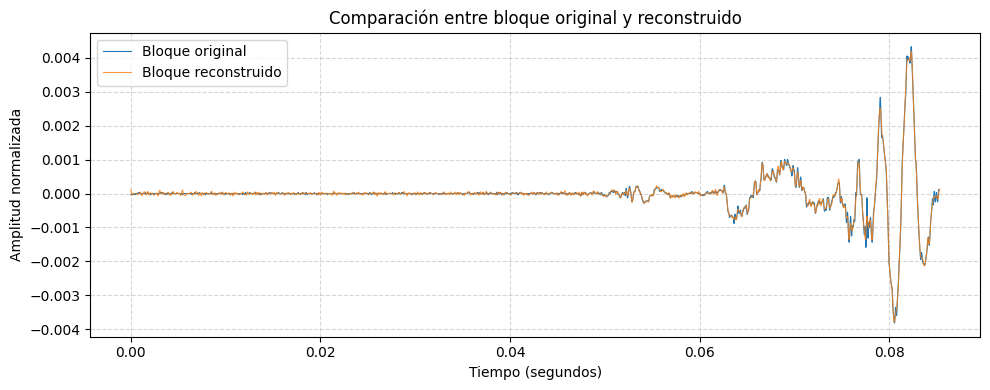

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_bloque_original_reconstruido.png')

In [100]:
tiempos_bloque = np.arange(N) / Fs
ruta_figura_bloque_reconstruido = carpeta_figuras_audio / "audio_bloque_original_reconstruido.png"

plt.figure(figsize=(10, 4))
plt.plot(tiempos_bloque, bloque, label="Bloque original", linewidth=0.8)
plt.plot(tiempos_bloque, bloque_reconstruido, label="Bloque reconstruido", linewidth=0.8, alpha=0.8)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud normalizada")
plt.title("Comparación entre bloque original y reconstruido")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_figura_bloque_reconstruido, dpi=300)
plt.show()

ruta_figura_bloque_reconstruido


Este primer experimento muestra la idea básica de la compresión espectral: al conservar solo una parte de los coeficientes de Fourier, obtenemos una señal aproximada. En el siguiente paso aplicaremos el mismo procedimiento a todos los bloques del audio.

## Compresión del audio completo por bloques

Aplicamos ahora el procedimiento anterior a toda la señal. Para ello dividimos el audio en bloques de longitud $N=4096$ (como el que acabamos de analizar). Si el último bloque no tiene longitud completa, añadimos ceros al final para poder aplicar la FFT con el mismo tamaño en todos los bloques ("zero-padding").

In [101]:
def comprimir_bloque_fft(bloque, porcentaje):
    """Comprime un bloque conservando un porcentaje de coeficientes de mayor modulo."""
    n = len(bloque)

    # Calculamos la FFT del bloque con la normalizacion usada en el trabajo.
    bloque_hat = np.fft.fft(bloque) / n

    # Determinamos cuantos coeficientes se van a conservar.
    num_coeficientes = max(1, int(porcentaje * n))

    # Elegimos el umbral que deja activos los coeficientes de mayor modulo.
    modulos = np.abs(bloque_hat)
    umbral = np.partition(modulos, -num_coeficientes)[-num_coeficientes]

    # Aplicamos la mascara y reconstruimos el bloque desde el espectro comprimido.
    mascara = modulos >= umbral
    bloque_hat_comprimido = bloque_hat * mascara
    bloque_reconstruido = reconstruir_desde_dft(bloque_hat_comprimido)

    return bloque_reconstruido, np.count_nonzero(mascara)


def comprimir_audio_por_bloques(audio, N, porcentaje):
    """Comprime una señal de audio dividiendola en bloques de longitud fija."""
    longitud_original = len(audio)

    # Calculamos cuantas muestras faltan para completar el ultimo bloque.
    resto = longitud_original % N
    padding = 0 if resto == 0 else N - resto

    # Añadimos ceros al final si la longitud no es multiplo de N.
    audio_padded = np.pad(audio, (0, padding))

    bloques_reconstruidos = []
    coeficientes_totales = 0

    # Procesamos cada bloque de forma independiente.
    for inicio in range(0, len(audio_padded), N):
        bloque = audio_padded[inicio:inicio + N]
        bloque_reconstruido, conservados = comprimir_bloque_fft(bloque, porcentaje)
        bloques_reconstruidos.append(bloque_reconstruido)
        coeficientes_totales += conservados

    # Unimos los bloques y eliminamos el padding para recuperar la duracion original.
    audio_reconstruido = np.concatenate(bloques_reconstruidos)[:longitud_original]

    return audio_reconstruido, coeficientes_totales, len(audio_padded), padding


In [102]:
porcentaje_audio = 0.10

audio_reconstruido, coeficientes_totales, longitud_padded, padding = comprimir_audio_por_bloques(
    audio, N, porcentaje_audio
)

error_audio = np.mean((audio - audio_reconstruido) ** 2)
porcentaje_real_audio = coeficientes_totales / longitud_padded

print(f"Longitud original: {len(audio)} muestras")
print(f"Longitud con padding: {longitud_padded} muestras")
print(f"Padding añadido: {padding} muestras")
print(f"Coeficientes conservados: {coeficientes_totales} de {longitud_padded}")
print(f"Porcentaje real conservado: {porcentaje_real_audio:.2%}")
print(f"Error cuadratico medio: {error_audio:.6e}")


Longitud original: 300168 muestras
Longitud con padding: 303104 muestras
Padding añadido: 2936 muestras
Coeficientes conservados: 30271 de 303104
Porcentaje real conservado: 9.99%
Error cuadratico medio: 3.721942e-05


Guardamos la señal reconstruida como un nuevo archivo WAV. Para ello deshacemos la normalización pasando de nuevo a enteros de 16 bits.

In [103]:
ruta_audio_reconstruido = ruta_audio.parent / "audio_reconstruido_10.wav"

# Evitamos que posibles pequeños excesos numericos salgan del intervalo [-1, 1].
audio_salida = np.clip(audio_reconstruido, -1, 1)

# Convertimos de valores reales normalizados a enteros de 16 bits.
audio_salida_int16 = (audio_salida * 32767).astype(np.int16)

with wave.open(str(ruta_audio_reconstruido), "wb") as archivo_wav:
    archivo_wav.setnchannels(1)
    archivo_wav.setsampwidth(2)
    archivo_wav.setframerate(Fs)
    archivo_wav.writeframes(audio_salida_int16.tobytes())

ruta_audio_reconstruido


PosixPath('/Users/tomi/Desktop/TFGMAT/audio/audio_reconstruido_10.wav')

El archivo reconstruido permite escuchar el efecto de conservar solo una parte de los coeficientes frecuenciales en cada bloque. El error cuadrático medio cuantifica la diferencia entre la señal original y la reconstruida, mientras que el porcentaje conservado indica cuánta información espectral se ha mantenido en este modelo simplificado.

## Comparación entre audio original y reconstruido

Comparamos ahora la señal original con la señal reconstruida tras conservar aproximadamente el $10\%$ de los coeficientes en cada bloque. Para que la comparación sea visible, representamos solo un intervalo corto del audio.

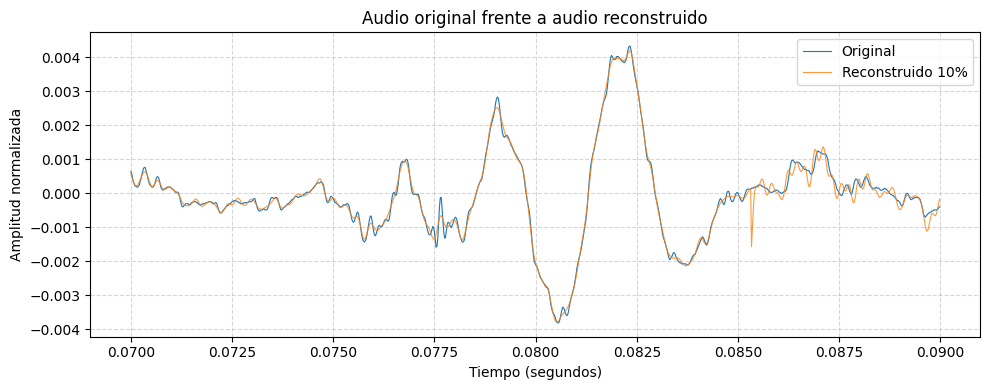

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_original_vs_reconstruido_10.png')

In [104]:
# Elegimos un intervalo corto para comparar las formas de onda.
inicio_comparacion = 0.07
duracion_comparacion = 0.02

muestra_inicio = int(inicio_comparacion * Fs)
muestra_fin = muestra_inicio + int(duracion_comparacion * Fs)

tiempos_comparacion = tiempos[muestra_inicio:muestra_fin]
audio_original_comparacion = audio[muestra_inicio:muestra_fin]
audio_reconstruido_comparacion = audio_reconstruido[muestra_inicio:muestra_fin]

ruta_figura_audio_comparacion = carpeta_figuras_audio / "audio_original_vs_reconstruido_10.png"

plt.figure(figsize=(10, 4))
plt.plot(tiempos_comparacion, audio_original_comparacion, label="Original", linewidth=0.8)
plt.plot(tiempos_comparacion, audio_reconstruido_comparacion, label="Reconstruido 10%", linewidth=0.8, alpha=0.8)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud normalizada")
plt.title("Audio original frente a audio reconstruido")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_figura_audio_comparacion, dpi=300)
plt.show()

ruta_figura_audio_comparacion


La señal reconstruida conserva la forma general de la señal original, aunque no coincide exactamente con ella. Esta diferencia es esperable, ya que al anular parte de los coeficientes de Fourier hemos eliminado información del espectro.

Para ver mejor la diferencia entre ambas señales, representamos también el error temporal en el mismo intervalo usado para la comparación:

$$
e[k]=f[k]-\widetilde f[k].
$$

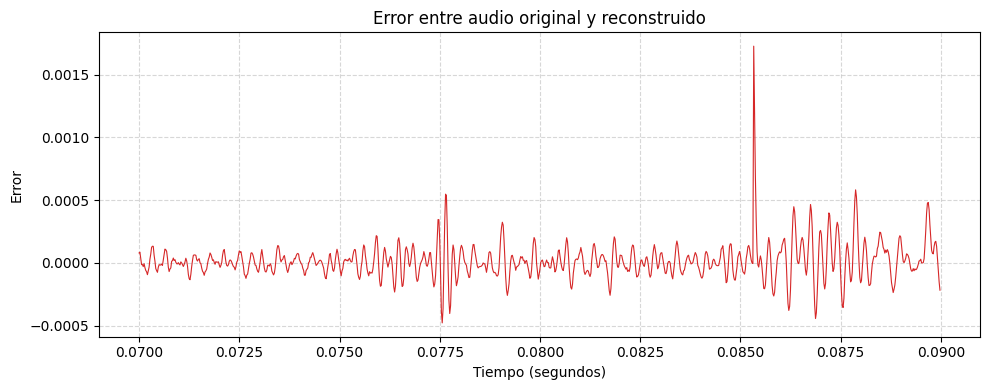

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_error_temporal_10.png')

In [105]:
# Calculamos el error entre la señal original y la reconstruida.
error_temporal = audio - audio_reconstruido
error_comparacion = error_temporal[muestra_inicio:muestra_fin]

ruta_figura_audio_error = carpeta_figuras_audio / "audio_error_temporal_10.png"

plt.figure(figsize=(10, 4))
plt.plot(tiempos_comparacion, error_comparacion, color="tab:red", linewidth=0.8)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Error")
plt.title("Error entre audio original y reconstruido")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(ruta_figura_audio_error, dpi=300)
plt.show()

ruta_figura_audio_error


El error no es nulo porque la reconstrucción se ha realizado a partir de un espectro incompleto. Aun así, su magnitud permite valorar hasta qué punto la señal reconstruida se mantiene cercana a la original para este porcentaje de coeficientes conservados.

## Comparación para distintos porcentajes de coeficientes

Finalmente repetimos la compresión para varios porcentajes de coeficientes conservados. Así podemos observar el compromiso entre reducir la información frecuencial almacenada y aumentar el error de reconstrucción. Para cada porcentaje generamos también un archivo WAV reconstruido.

In [106]:
porcentajes = [0.01, 0.05, 0.10, 0.20]
resultados_audio = []

for porcentaje in porcentajes:
    # Comprimimos el audio completo con el porcentaje indicado.
    audio_rec, coeficientes, longitud_padded, padding = comprimir_audio_por_bloques(
        audio, N, porcentaje
    )

    # Calculamos medidas de comparacion con el audio original.
    error = np.mean((audio - audio_rec) ** 2)
    porcentaje_real = coeficientes / longitud_padded

    # Guardamos cada audio reconstruido en un archivo WAV independiente.
    nombre_salida = f"audio_reconstruido_{int(porcentaje * 100):02d}.wav"
    ruta_salida = ruta_audio.parent / nombre_salida

    audio_salida = np.clip(audio_rec, -1, 1)
    audio_salida_int16 = (audio_salida * 32767).astype(np.int16)

    with wave.open(str(ruta_salida), "wb") as archivo_wav:
        archivo_wav.setnchannels(1)
        archivo_wav.setsampwidth(2)
        archivo_wav.setframerate(Fs)
        archivo_wav.writeframes(audio_salida_int16.tobytes())

    resultados_audio.append([
        porcentaje, porcentaje_real, coeficientes, longitud_padded, error, ruta_salida
    ])

resultados_audio


[[0.01,
  np.float64(0.009765625),
  np.int64(2960),
  303104,
  np.float64(0.001857040572507706),
  PosixPath('/Users/tomi/Desktop/TFGMAT/audio/audio_reconstruido_01.wav')],
 [0.05,
  np.float64(0.049824482685810814),
  np.int64(15102),
  303104,
  np.float64(0.00013696411327625052),
  PosixPath('/Users/tomi/Desktop/TFGMAT/audio/audio_reconstruido_05.wav')],
 [0.1,
  np.float64(0.09987001161317567),
  np.int64(30271),
  303104,
  np.float64(3.7219416662097034e-05),
  PosixPath('/Users/tomi/Desktop/TFGMAT/audio/audio_reconstruido_10.wav')],
 [0.2,
  np.float64(0.19995447107263514),
  np.int64(60607),
  303104,
  np.float64(8.939533525807017e-06),
  PosixPath('/Users/tomi/Desktop/TFGMAT/audio/audio_reconstruido_20.wav')]]

Mostramos los resultados en forma de tabla. El error cuadrático medio aumenta cuando conservamos menos coeficientes, mientras que el porcentaje conservado indica la fracción de coeficientes frecuenciales que se han mantenido en el modelo simplificado.

In [107]:
print(f"{'porcentaje':>12} {'real':>10} {'coeficientes':>14} {'error MSE':>14} {'archivo':>32}")
print('-' * 90)

for porcentaje, porcentaje_real, coeficientes, longitud_padded, error, ruta_salida in resultados_audio:
    print(
        f"{porcentaje:12.0%} {porcentaje_real:10.2%} {coeficientes:14d} "
        f"{error:14.6e} {ruta_salida.name:>32}"
    )


  porcentaje       real   coeficientes      error MSE                          archivo
------------------------------------------------------------------------------------------
          1%      0.98%           2960   1.857041e-03        audio_reconstruido_01.wav
          5%      4.98%          15102   1.369641e-04        audio_reconstruido_05.wav
         10%      9.99%          30271   3.721942e-05        audio_reconstruido_10.wav
         20%     20.00%          60607   8.939534e-06        audio_reconstruido_20.wav


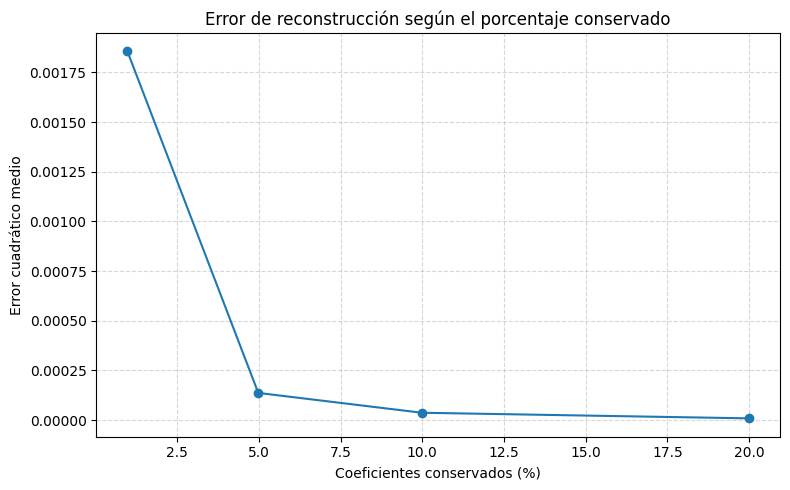

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_error_porcentaje.png')

In [108]:
porcentajes_reales = [fila[1] * 100 for fila in resultados_audio]
errores_audio = [fila[4] for fila in resultados_audio]

ruta_figura_error_porcentaje = carpeta_figuras_audio / "audio_error_porcentaje.png"

plt.figure(figsize=(8, 5))
plt.plot(porcentajes_reales, errores_audio, marker="o")
plt.xlabel("Coeficientes conservados (%)")
plt.ylabel("Error cuadrático medio")
plt.title("Error de reconstrucción según el porcentaje conservado")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(ruta_figura_error_porcentaje, dpi=300)
plt.show()

ruta_figura_error_porcentaje


La tabla y la gráfica resumen el comportamiento esperado: al conservar más coeficientes, el error de reconstrucción disminuye. Esto muestra el compromiso propio de una compresión con pérdida: usar menos coeficientes reduce la información necesaria para representar la señal, pero aumenta la diferencia respecto al audio original.

## Comparación con una compresión global de la señal

Hasta ahora hemos aplicado la compresión por bloques. En esta nueva sección compararemos este procedimiento con una compresión global, en la que se calcula una única FFT de toda la señal y se conserva el mismo porcentaje de coeficientes de mayor módulo sobre el audio completo.

El objetivo es estudiar si trabajar por bloques ayuda a conservar mejor información local de la señal. Si se seleccionan los coeficientes más grandes de forma global, pueden perderse componentes que son relevantes en un tramo concreto del audio, aunque no estén entre los coeficientes dominantes de toda la señal.

Para construir la comparación global usaremos el mismo criterio que antes: conservar el 10 % de los coeficientes de mayor módulo. La diferencia es que ahora la FFT se aplica una sola vez a toda la señal, en lugar de aplicarse por separado a cada bloque.

In [109]:
def siguiente_potencia_de_dos(n):
    """Devuelve la menor potencia de 2 mayor o igual que n."""
    return 1 if n <= 1 else 2 ** int(np.ceil(np.log2(n)))


def comprimir_audio_global(audio, porcentaje):
    """Comprime toda la señal con una unica FFT global."""
    longitud_original = len(audio)

    # Completamos con ceros hasta una potencia de 2 para mantener el marco radix-2.
    longitud_padded = siguiente_potencia_de_dos(longitud_original)
    padding = longitud_padded - longitud_original
    audio_padded = np.pad(audio, (0, padding))

    # Calculamos la FFT global con la normalizacion usada en el trabajo.
    audio_hat = np.fft.fft(audio_padded) / longitud_padded

    # Conservamos los coeficientes de mayor modulo en toda la señal.
    num_coeficientes = max(1, int(porcentaje * longitud_padded))
    modulos = np.abs(audio_hat)
    umbral = np.partition(modulos, -num_coeficientes)[-num_coeficientes]
    mascara = modulos >= umbral

    audio_hat_comprimido = audio_hat * mascara
    audio_reconstruido = reconstruir_desde_dft(audio_hat_comprimido)[:longitud_original]

    return audio_reconstruido, np.count_nonzero(mascara), longitud_padded, padding


Aplicamos ahora esta compresión global con el mismo porcentaje utilizado antes. Así tendremos una reconstrucción por bloques y otra global comparables entre sí.

In [110]:
audio_reconstruido_global, coeficientes_globales, longitud_padded_global, padding_global = comprimir_audio_global(
    audio, porcentaje_audio
)

error_audio_global = np.mean((audio - audio_reconstruido_global) ** 2)
porcentaje_real_global = coeficientes_globales / longitud_padded_global

print(f"Longitud original: {len(audio)} muestras")
print(f"Longitud global con padding: {longitud_padded_global} muestras")
print(f"Padding añadido: {padding_global} muestras")
print(f"Coeficientes conservados: {coeficientes_globales} de {longitud_padded_global}")
print(f"Porcentaje real conservado: {porcentaje_real_global:.2%}")
print(f"Error cuadratico medio global: {error_audio_global:.6e}")


Longitud original: 300168 muestras
Longitud global con padding: 524288 muestras
Padding añadido: 224120 muestras
Coeficientes conservados: 52428 de 524288
Porcentaje real conservado: 10.00%
Error cuadratico medio global: 4.885431e-05


In [111]:
ruta_audio_global_10 = ruta_audio.parent / "audio_reconstruido_global_10.wav"

audio_global_salida = np.clip(audio_reconstruido_global, -1, 1)
audio_global_int16 = (audio_global_salida * 32767).astype(np.int16)

with wave.open(str(ruta_audio_global_10), "wb") as archivo_wav:
    archivo_wav.setnchannels(1)
    archivo_wav.setsampwidth(2)
    archivo_wav.setframerate(Fs)
    archivo_wav.writeframes(audio_global_int16.tobytes())

ruta_audio_global_10


PosixPath('/Users/tomi/Desktop/TFGMAT/audio/audio_reconstruido_global_10.wav')

Comparamos ahora los dos métodos con el mismo porcentaje nominal de coeficientes conservados. El error cuadrático medio mide la diferencia promedio entre el audio original y cada reconstrucción.

In [112]:
print(f"{'metodo':>12} {'coeficientes (%)':>18} {'error MSE':>14}")
print('-' * 50)
print(f"{'bloques':>12} {porcentaje_real_audio:18.2%} {error_audio:14.6e}")
print(f"{'global':>12} {porcentaje_real_global:18.2%} {error_audio_global:14.6e}")


      metodo   coeficientes (%)      error MSE
--------------------------------------------------
     bloques              9.99%   3.721942e-05
      global             10.00%   4.885431e-05


Mostramos ahora un mismo fragmento temporal del audio original y de las dos reconstrucciones. Esta gráfica no sustituye al error numérico, pero permite comparar visualmente cómo sigue cada método la forma de la señal en un tramo concreto.

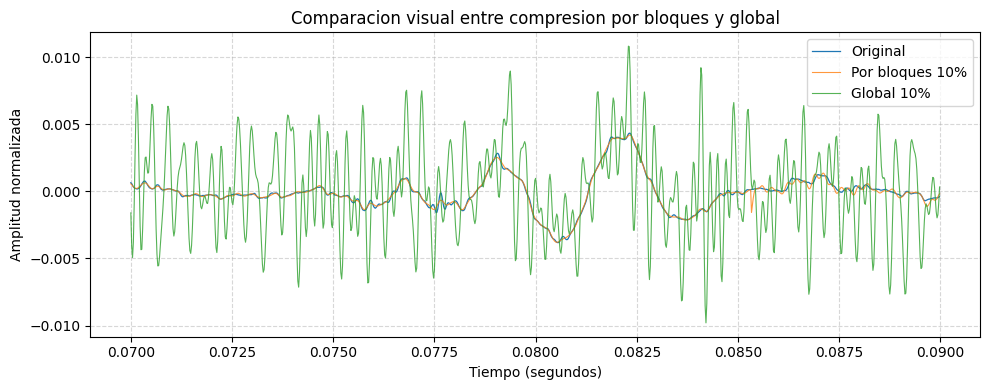

PosixPath('/Users/tomi/Desktop/TFGMAT/figuras/audio_bloques_vs_global_10.png')

In [113]:
audio_reconstruido_global_comparacion = audio_reconstruido_global[muestra_inicio:muestra_fin]

ruta_figura_comparacion_global = carpeta_figuras_audio / "audio_bloques_vs_global_10.png"

plt.figure(figsize=(10, 4))
plt.plot(tiempos_comparacion, audio_original_comparacion, label="Original", linewidth=0.9)
plt.plot(tiempos_comparacion, audio_reconstruido_comparacion, label="Por bloques 10%", linewidth=0.8, alpha=0.8)
plt.plot(tiempos_comparacion, audio_reconstruido_global_comparacion, label="Global 10%", linewidth=0.8, alpha=0.8)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud normalizada")
plt.title("Comparacion visual entre compresion por bloques y global")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_figura_comparacion_global, dpi=300)
plt.show()

ruta_figura_comparacion_global


En este fragmento se aprecia claramente que la reconstrucción por bloques sigue mucho mejor la forma de la señal original, mientras que la compresión global presenta oscilaciones mucho más alejadas del audio inicial. Esta diferencia local no aparece con tanta fuerza en el error cuadrático medio global porque el MSE se promedia sobre toda la señal: un error grande en un tramo concreto queda diluido al considerar todas las muestras del audio. Por tanto, la gráfica muestra la ventaja principal de trabajar por bloques: el criterio de conservación de coeficientes se adapta a cada tramo de la señal, en lugar de seleccionar únicamente los coeficientes más grandes del audio completo.